In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd
import numpy as np

In [ ]:
# see the data
iris_data = load_iris()
df = pd.DataFrame(data=iris_data.data, columns=iris_data.feature_names)
df['target'] = iris_data.target
df.head()

# 

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [4]:
# split the data
X = df[iris_data.feature_names]
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression() # doc : https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
model.fit(X_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [5]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")


Accuracy: 1.00


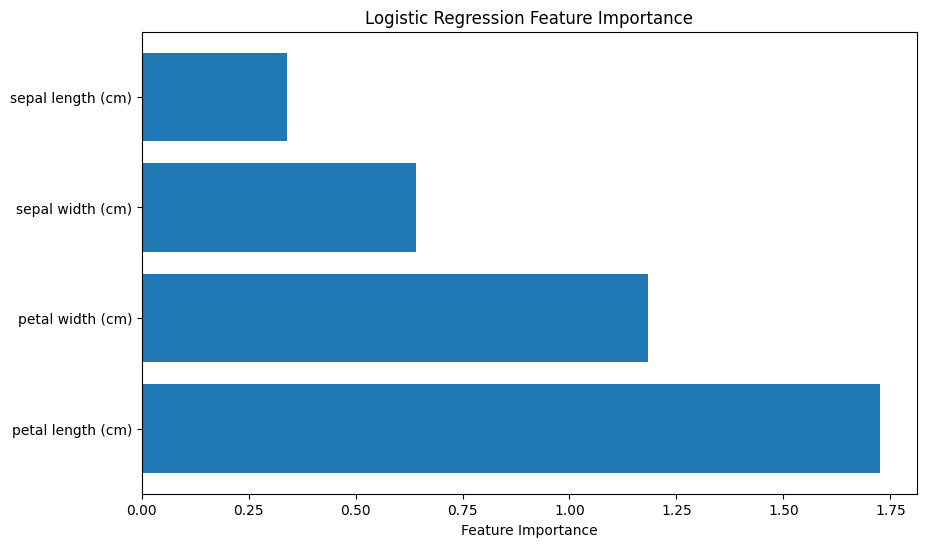

In [ ]:
model.coef_
# avg feature importance
weight_vector = np.mean(np.abs(model.coef_), axis=0)
bias = np.mean(np.abs(model.intercept_))
feature_names = iris_data.feature_names

# Feature Importance
feature_importance = pd.DataFrame({'Feature': feature_names, 'Weight': weight_vector})
feature_importance = feature_importance.sort_values(by='Weight', ascending=False)

# plot it
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Weight'])
plt.xlabel('Feature Importance')
plt.title('Logistic Regression Feature Importance')
plt.show()

# +ve weight means the feature is positively correlated with the target variable: if you increase the feature, the probability of the positive class increases
# -ve weight means the feature is negatively correlated with the target variable
